In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt

rng = jr.key(123)


[(-4.0, 4.0), (-4.0, 4.0)]

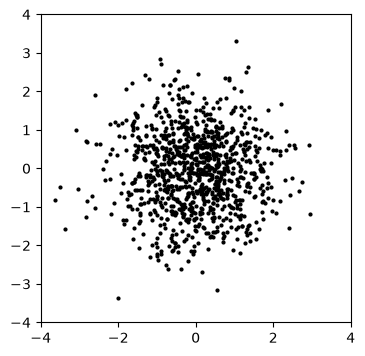

In [3]:
n_points = 1000
rng,key = jr.split(rng)
points = jr.normal(key, (n_points,2))

plt.figure(figsize=(4,4))
plt.scatter(*points.T, s = 4, c = "k")
plt.gca().set(xlim=(-4,4), ylim=(-4,4))

In [5]:
def matern_32(r,rho=0.5):
    result = (1+jnp.sqrt(3)*r/rho)*jnp.exp(-jnp.sqrt(3)*r/rho)
    result *= 1+1e-4*(r==0)
    return result

[(-4.0, 4.0), (-4.0, 4.0)]

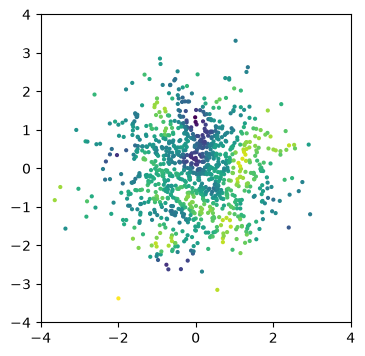

In [10]:
rng, key = jr.split(rng)
xi = jr.normal(key, (n_points,))

pair = jnp.linalg.norm(points[:, None] -points[None, :], axis=-1)
K = matern_32(pair)
L = jnp.linalg.cholesky(K)
values = L @ xi

plt.figure(figsize=(4,4))
plt.scatter(*points.T, s = 4, c = values)
plt.gca().set(xlim=(-4,4), ylim=(-4,4))

[(-4.0, 4.0), (-4.0, 4.0)]

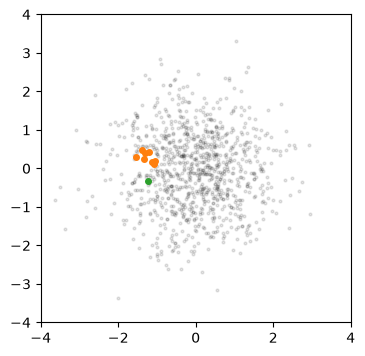

In [18]:
k = 8
preceding_pair = jnp.tril(pair)
preceding_pair = jnp.where(preceding_pair==0, jnp.inf, preceding_pair)
neighbors = jnp.argsort(preceding_pair, axis=-1)[:,:k]

plt.figure(figsize=(4,4))
plt.scatter(*points.T, c ="k", alpha=0.1, s=4)
plt.scatter(*points[neighbors[900]].T, c = "C1", s=16)
plt.scatter(*points[10].T, s = 16, c ="C2")

plt.gca().set(xlim=(-4,4), ylim=(-4,4))

In [ ]:
joint_points = jnp.concatenate([points[neighbors], points[:, None]], axis=)
joint_pairs = jnp.linalg.norm(joint_points[:, None] - joint_points[:,:,None])
joint_K = matern_32(joint_pairs)
joint_L = jnp.linalg.cholesky(joint_K)

first_points = points[K]
first_pairs = jnp.linalg.norm(first_points[:, None] -first_points[None, :])
first_K = matern_32(first_pairs)
first_L = jnp.linalg.cholesky(first_K)
first_values = first_L@xi[:k]

vecchia_values = jnp.zeros(n_points)
vecchia_values = vecchia_values.at[:k].set(first_values)

for i in range(k, n_points):
    neighbors_values = vecchia_values[neighbors[i]]
    neighbor_xi = 

TypeError: transpose permutation isn't a permutation of operand dimensions, got permutation (-1, -2) for operand shape ().